# Import Libraries

In [125]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn import tree, ensemble
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.model_selection import train_test_split

# Naive Approach


In [126]:
data= pd.read_csv('dataset1.csv')
print(data.head())

     N    P    K    pH    EC    OC     S    Zn    Fe    Cu    Mn     B  \
0  138  8.6  560  7.46  0.62  0.70   5.9  0.24  0.31  0.77  8.71  0.11   
1  213  7.5  338  7.62  0.75  1.06  25.4  0.30  0.86  1.54  2.89  2.29   
2  163  9.6  718  7.59  0.51  1.11  14.3  0.30  0.86  1.57  2.70  2.03   
3  157  6.8  475  7.64  0.58  0.94  26.0  0.34  0.54  1.53  2.65  1.82   
4  270  9.9  444  7.63  0.40  0.86  11.8  0.25  0.76  1.69  2.43  2.26   

   fertility  
0          0  
1          0  
2          0  
3          0  
4          1  


In [127]:
target_data=data['fertility']
input_data=data.drop('fertility',axis=1)

In [128]:
naiveTrainInput, naiveValidationInput, naiveTrainTarget, naiveValidationTarget = train_test_split(input_data, target_data, test_size = 0.2, shuffle=True, random_state = 42)
print("Naive Train Data Shape: ", naiveTrainInput.shape)

Naive Train Data Shape:  (704, 12)


In [129]:
naiveTrainTarget = naiveTrainTarget.values.ravel()

In [130]:
naiveClf = ensemble.RandomForestClassifier()
naiveClf.fit(naiveTrainInput, naiveTrainTarget)

RandomForestClassifier()

In [131]:
naivePred = naiveClf.predict((naiveValidationInput))

In [132]:
naiveAcc = accuracy_score(naiveValidationTarget, naivePred)
print("Naive Accuracy : ", naiveAcc)

Naive Accuracy :  0.875


# Get the Modified data

In [133]:
from ydata_profiling import ProfileReport


In [134]:
data=pd.read_csv("C:/Users/Taran/Desktop/KrishiAi/Raw Data Soil Fettility.csv")
print(data.head(),"\n")
print(data.info(),"\n")

profile=ProfileReport(data)
profile.to_widgets()
profile.to_file("Soil_Data.html")
# we have no catagorical values
print(data.describe(),"\n")

# There are no null values
print(data.isna().sum())
print(data.nunique())
print(data['fertility'].value_counts())
print(" 0- Describes low fertility\n 1- describes moderate fertility\n 2- describes good fertility")


     N    P    K    ph    ec    oc     S    zn    fe    cu    Mn     B  \
0  138  8.6  560  7.46  0.62  0.70   5.9  0.24  0.31  0.77  8.71  0.11   
1  213  7.5  338  7.62  0.75  1.06  25.4  0.30  0.86  1.54  2.89  2.29   
2  163  9.6  718  7.59  0.51  1.11  14.3  0.30  0.86  1.57  2.70  2.03   
3  157  6.8  475  7.64  0.58  0.94  26.0  0.34  0.54  1.53  2.65  1.82   
4  220  8.6  444  7.43  0.65  0.72  11.7  0.37  0.66  0.90  2.19  1.82   

   fertility  
0          0  
1          0  
2          0  
3          0  
4          0   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1288 entries, 0 to 1287
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   N          1288 non-null   int64  
 1   P          1288 non-null   float64
 2   K          1288 non-null   int64  
 3   ph         1288 non-null   float64
 4   ec         1288 non-null   float64
 5   oc         1288 non-null   float64
 6   S          1288 non-null   floa

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render widgets:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

                 N            P            K           ph           ec  \
count  1288.000000  1288.000000  1288.000000  1288.000000  1288.000000   
mean    269.061335    17.643478   497.135093     7.549130     0.535893   
std      80.542499    25.303343   120.887088     0.507163     0.134156   
min       6.000000     2.900000    11.000000     0.900000     0.100000   
25%     207.000000     7.200000   422.000000     7.340000     0.430000   
50%     289.000000     9.200000   465.000000     7.500000     0.530000   
75%     333.000000    13.800000   570.000000     7.700000     0.630000   
max     383.000000   125.000000   887.000000    11.150000     0.950000   

                oc            S           zn           fe           cu  \
count  1288.000000  1288.000000  1288.000000  1288.000000  1288.000000   
mean      0.632174     7.122888     0.442811     4.119185     0.911281   
std       0.720488     4.026723     1.568333     3.028314     0.448782   
min       0.100000     0.640000     0

In [135]:
corr=data.corr()
print("Correlation Matrix:")
corr

Correlation Matrix:


,N,P,K,ph,ec,oc,S,zn,fe,cu,Mn,B,fertility
N,1.000000,0.093832,0.038923,0.121486,-0.070546,0.008829,-0.235340,0.023866,0.099257,-0.256674,0.130461,-0.240333,0.659255
P,0.093832,1.000000,0.100911,0.016134,0.088453,-0.002942,-0.113835,-0.018667,0.100791,-0.069810,-0.059330,-0.101292,0.234447
K,0.038923,0.100911,1.000000,0.027218,-0.090475,-0.022500,0.058651,0.000427,-0.152482,-0.075039,0.030665,0.125149,0.001726
ph,0.121486,0.016134,0.027218,1.000000,0.018229,-0.029233,0.027662,-0.008797,-0.046303,0.015778,-0.020260,0.014457,0.127335
ec,-0.070546,0.088453,-0.090475,0.018229,1.000000,0.003355,0.099952,-0.024310,-0.086731,0.023008,0.005247,0.007272,-0.081856
oc,0.008829,-0.002942,-0.022500,-0.029233,0.003355,1.000000,0.043683,0.605668,0.210331,0.015133,-0.064141,0.090147,0.043513
S,-0.235340,-0.113835,0.058651,0.027662,0.099952,0.043683,1.000000,-0.006780,-0.216963,0.177997,-0.132230,0.429421,-0.157644
zn,0.023866,-0.018667,0.000427,-0.008797,-0.024310,0.605668,-0.006780,1.000000,0.467914,-0.030785,-0.054453,0.057715,-0.001295
fe,0.099257,0.100791,-0.152482,-0.046303,-0.086731,0.210331,-0.216963,0.467914,1.000000,0.186790,0.225458,-0.379040,0.010342
cu,-0.256674,-0.069810,-0.075039,0.015778,0.023008,0.015133,0.177997,-0.030785,0.186790,1.000000,0.068562,0.062537,-0.178057


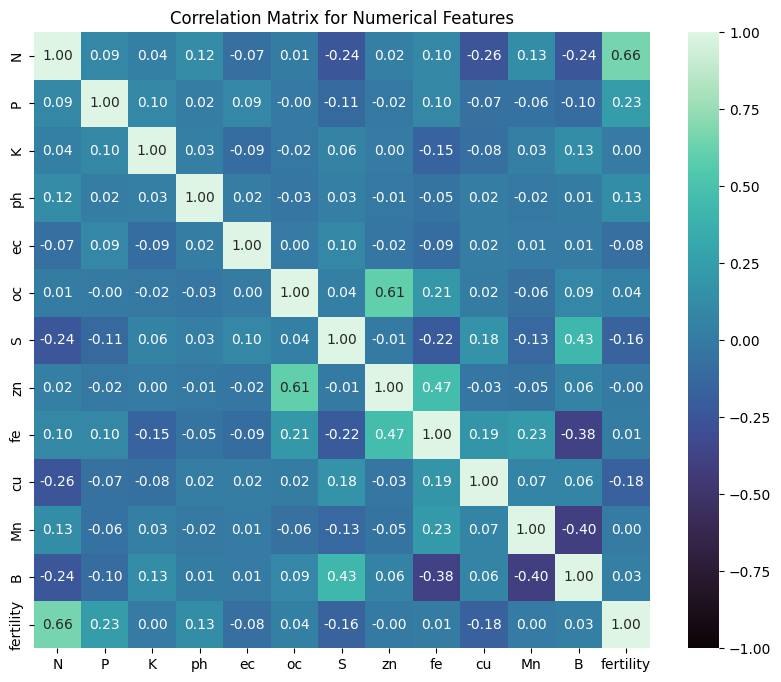

In [136]:
%matplotlib inline
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True,vmin=-1, vmax=1,fmt=".2f", cmap=sns.color_palette("mako", as_cmap=True),square=True)
plt.title("Correlation Matrix for Numerical Features")
plt.show()

In [137]:
label=data[['fertility']]
features=data.drop(['fertility'], axis=1)

In [138]:
label.head()

,fertility
0,0
1,0
2,0
3,0
4,0


In [139]:
features.head()

,N,P,K,ph,ec,oc,S,zn,fe,cu,Mn,B
0,138,8.6,560,7.46,0.62,0.70,5.9,0.24,0.31,0.77,8.71,0.11
1,213,7.5,338,7.62,0.75,1.06,25.4,0.30,0.86,1.54,2.89,2.29
2,163,9.6,718,7.59,0.51,1.11,14.3,0.30,0.86,1.57,2.70,2.03
3,157,6.8,475,7.64,0.58,0.94,26.0,0.34,0.54,1.53,2.65,1.82
4,220,8.6,444,7.43,0.65,0.72,11.7,0.37,0.66,0.90,2.19,1.82


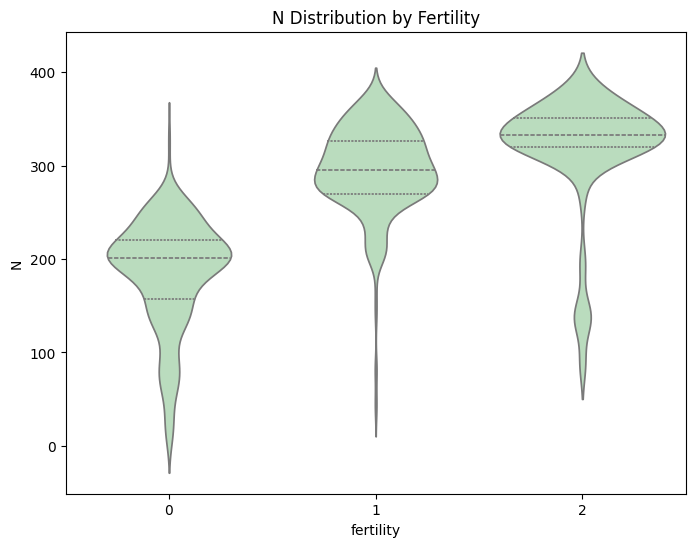

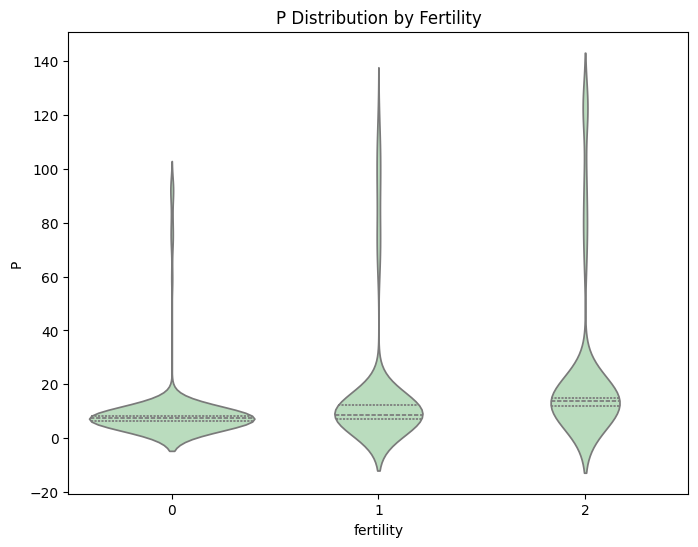

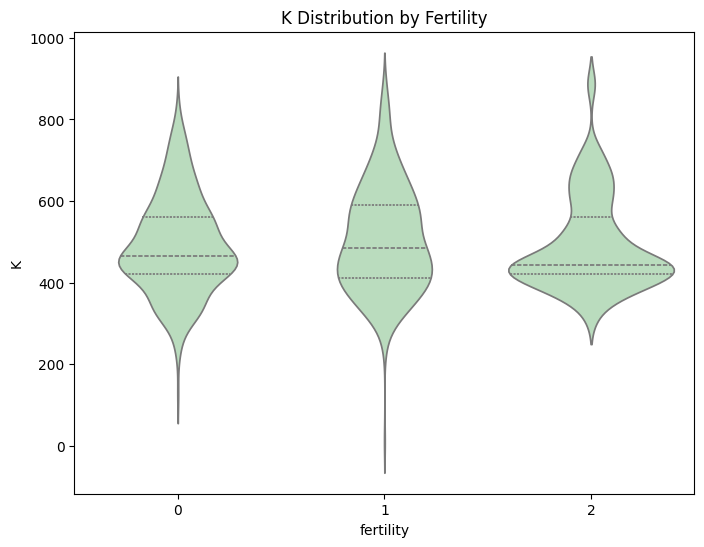

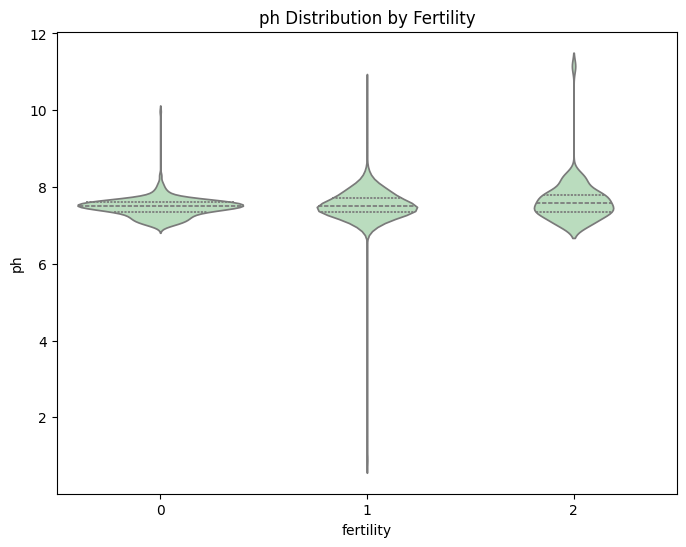

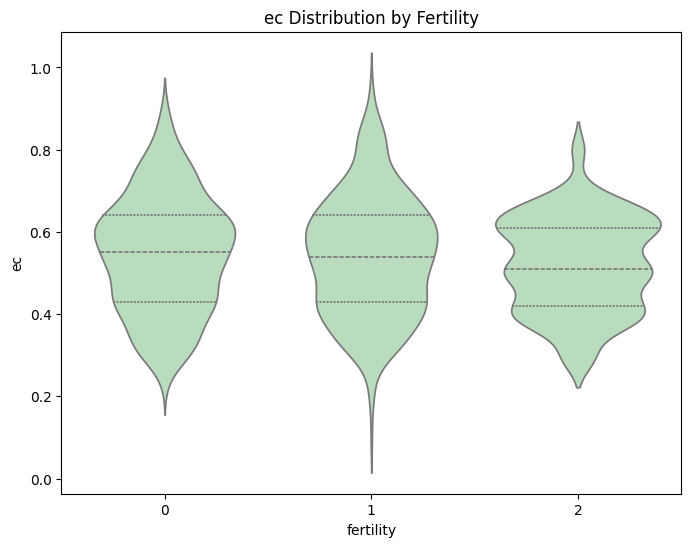

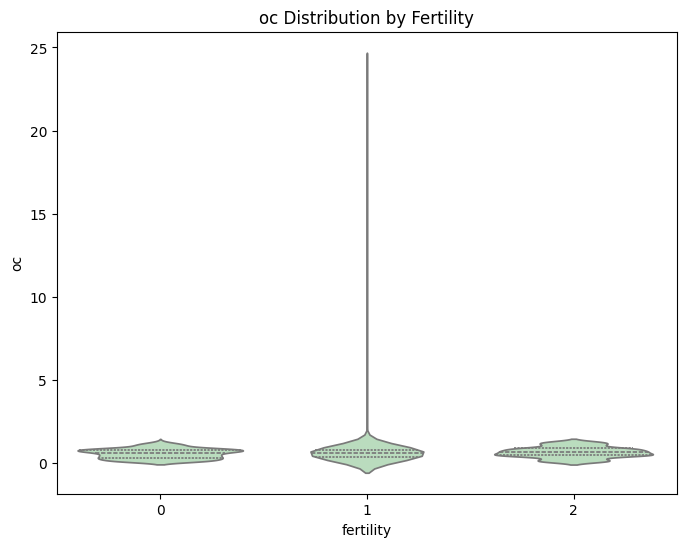

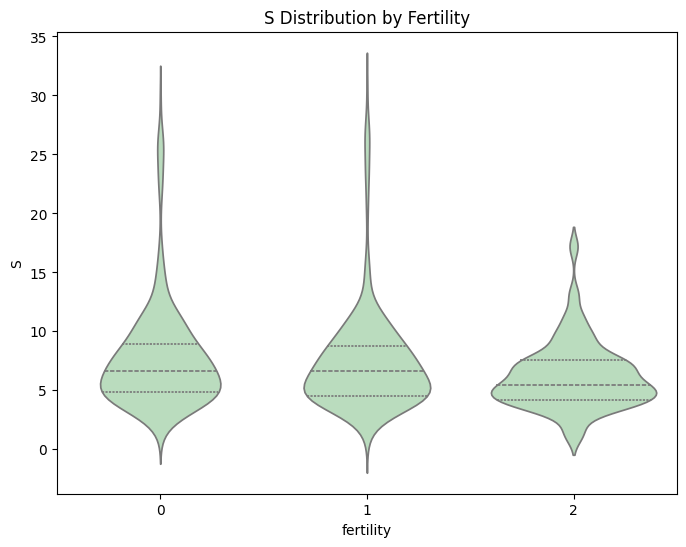

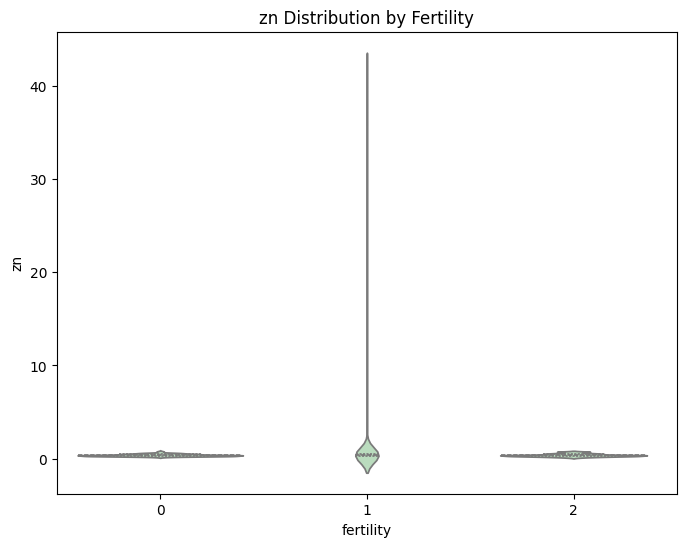

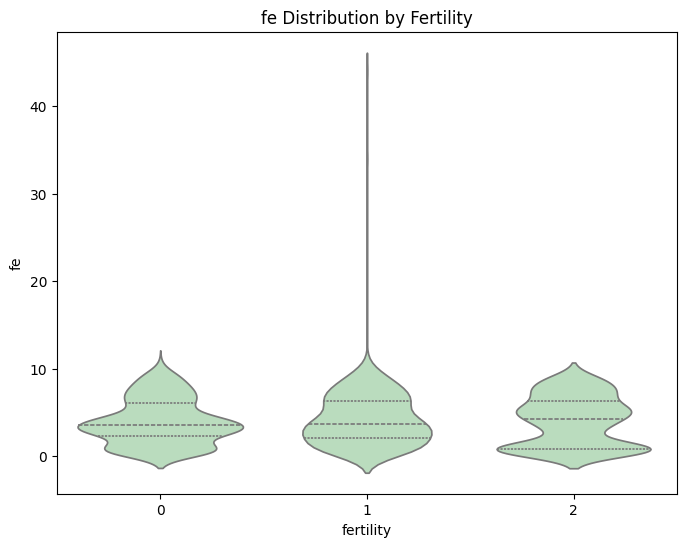

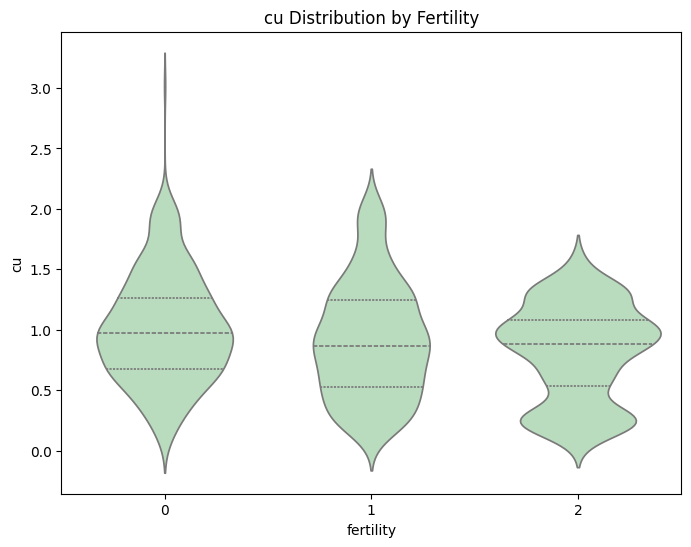

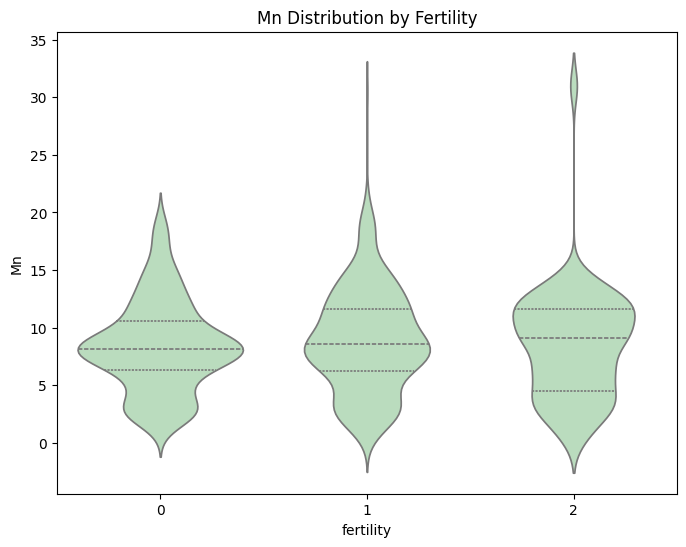

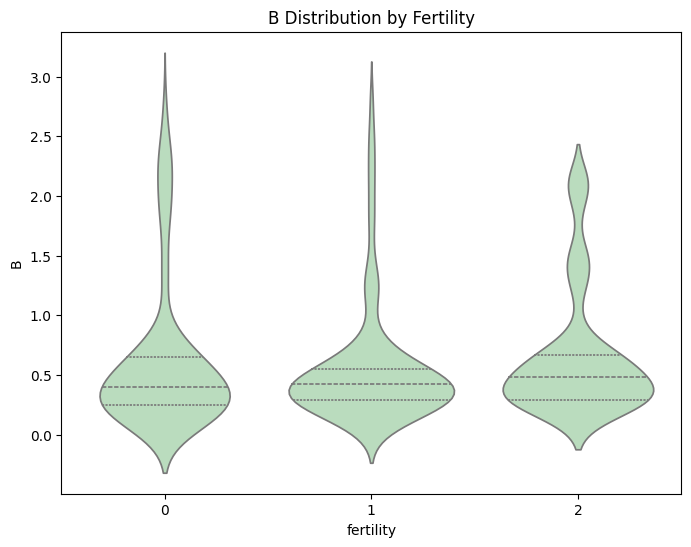

In [140]:
for feature in features:
    plt.figure(figsize=(8, 6))
    sns.violinplot(x='fertility', y=feature, data=data, inner="quart")
    plt.title(f'{feature} Distribution by Fertility')
    plt.show()

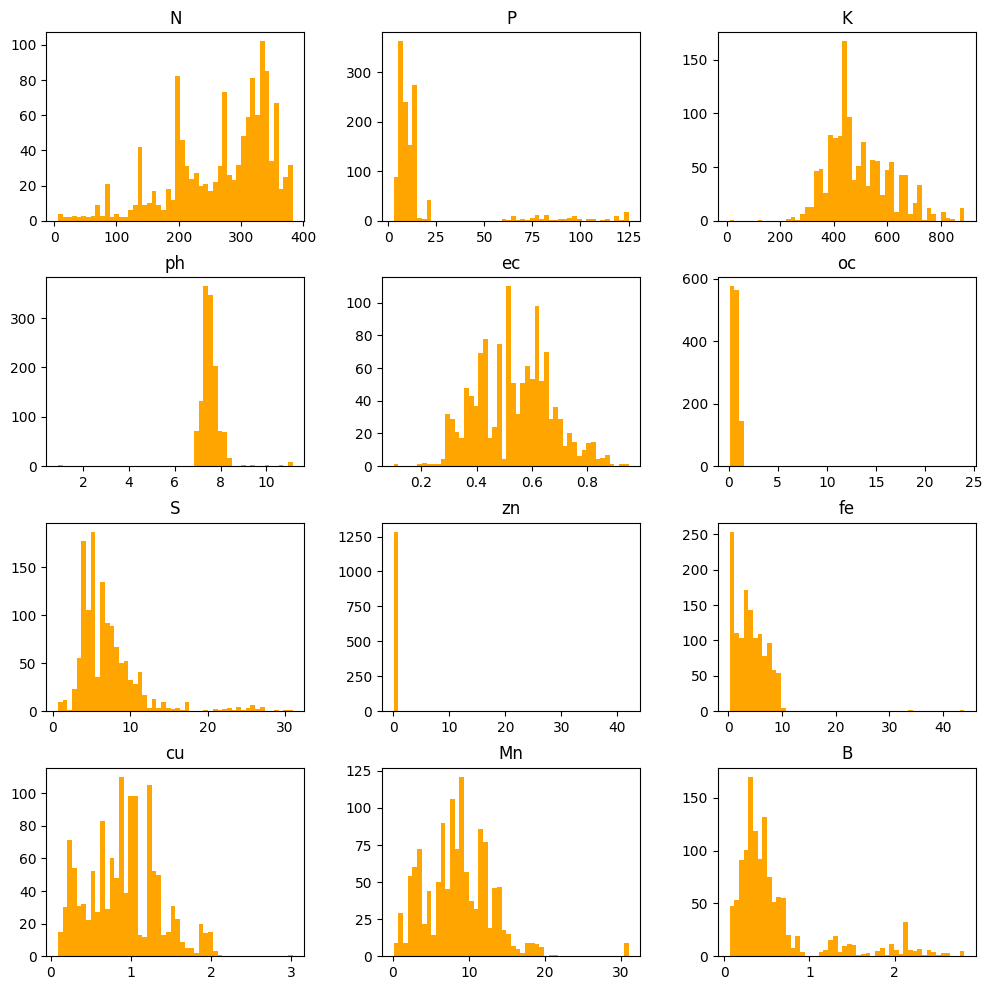

In [141]:
features.hist(bins=50,figsize=(12,12),color='orange', grid=False)
plt.show()

This shows skewed distribution


Converting skewed to normal distribution


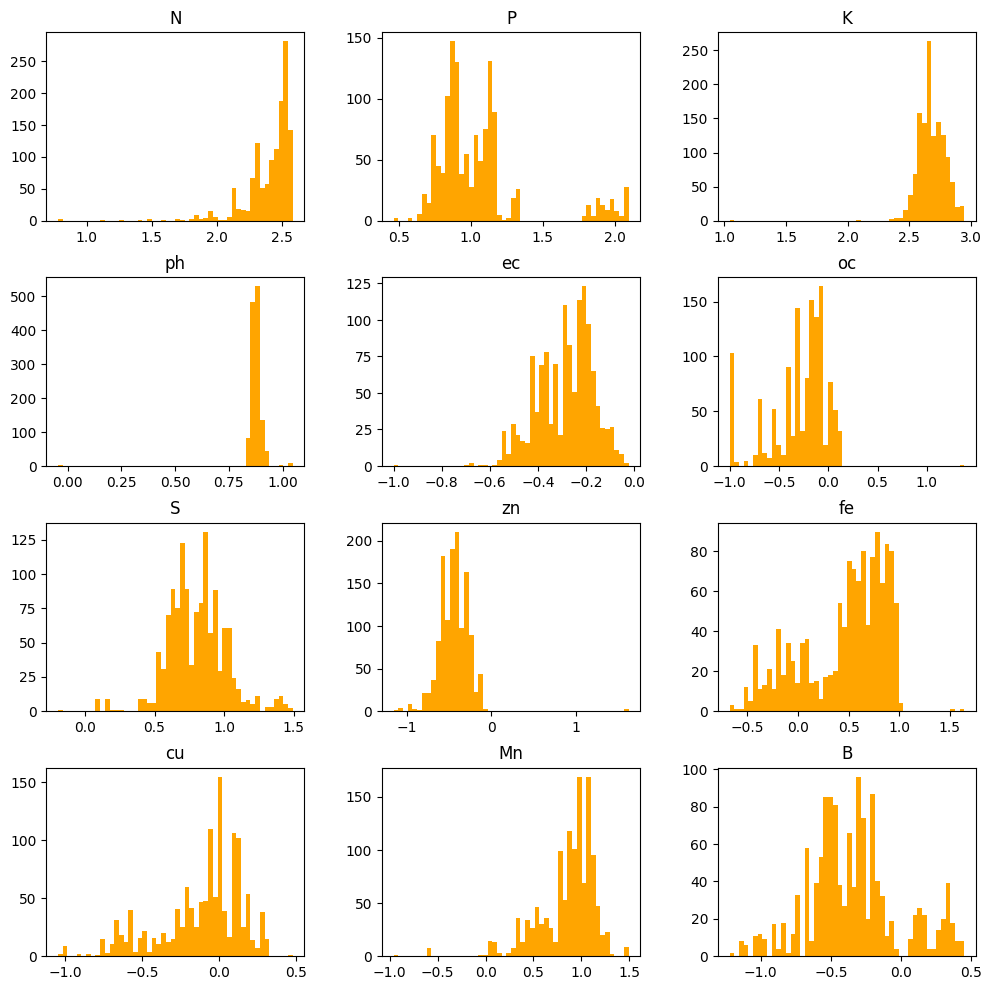

In [142]:
Features=features.apply( lambda x:np.log10(x) if np.issubdtype(x.dtype, np.number) else x)
Features.hist(bins=50, figsize=(12,12), color='orange',grid=False)
plt.show()

# Spliting the data 


In [143]:
trainInput, validationInput, trainTarget, validationTarget = train_test_split(Features, label, test_size = 0.2, shuffle=True, random_state = 42)
print("Train Data Shape: ", trainInput.shape)

Train Data Shape:  (1030, 12)


In [144]:
trainTarget = trainTarget.values.ravel()

# Choose Model

In [145]:
svcClf = SVC()
svcClf.fit(trainInput, trainTarget)

SVC()

In [146]:
forestClf = ensemble.RandomForestClassifier()
forestClf.fit(trainInput, trainTarget)

RandomForestClassifier()

In [147]:
nbClf = GaussianNB()
nbClf.fit(trainInput, trainTarget)

GaussianNB()

In [148]:
knnClf = KNeighborsClassifier()
knnClf.fit(trainInput, trainTarget)

KNeighborsClassifier()

In [149]:
treeClf = tree.DecisionTreeClassifier()
treeClf.fit(trainInput, trainTarget)

DecisionTreeClassifier()

SVC  accuarcy is  0.6511627906976745
RandomForestClassifier  accuarcy is  0.9728682170542635
GaussianNB  accuarcy is  0.5736434108527132
KNeighborsClassifier  accuarcy is  0.810077519379845
DecisionTreeClassifier  accuarcy is  0.9302325581395349


<Axes: >

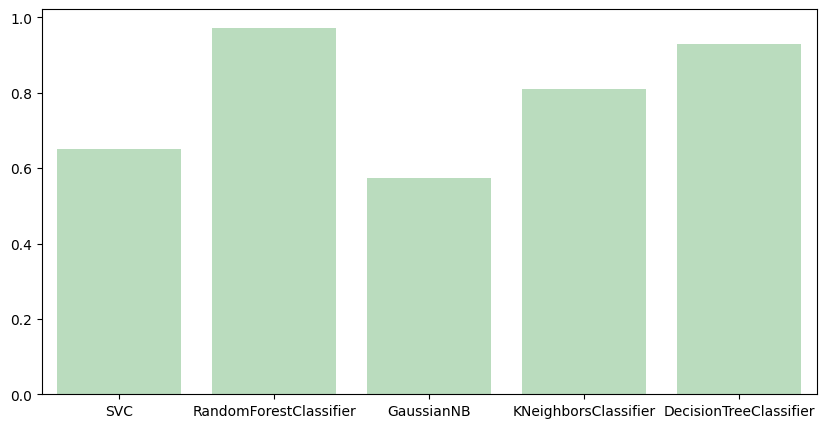

In [150]:
models = [svcClf, forestClf, nbClf, knnClf, treeClf]
accs = []
titles = []

for model in models:
    pred = model.predict((validationInput))
    model_acc = accuracy_score(validationTarget, pred)
    accs.append(model_acc)
    titles.append(type(model).__name__)
    print(type(model).__name__, " accuarcy is ", model_acc)

fig = plt.figure(figsize=(10, 5))
sns.color_palette("crest")
sns.barplot(x = titles, y=accs)

Pros & Cons

1. SVC

a) clear margin of separation between classes
b) more effective in high dimensional spaces
c) effective in cases where the number of dimensions is greater than the number of samples
d) memory efficient
e) not suitable for large data sets

2. Random Forest Classifier

a) quite fast
b) able to deal with unbalanced and missing data
c) may over-fit data sets that are particularly noisy
d) data-hungry

3. GaussianNB

a) very fast
b) better than other models with less training data if the assumption of independence of features holds
c) If you have categorical input variables, the Naive Bayes algorithm performs exceptionally well in comparison to numerical      variables
d) effectively works in Multi-class predictions.

4. KNeighborsClassifier

a) robust to noisy data
b) effective if the training data is large

5. DecisionTreeClassifier

a) does not require normalization of data
b) does not require scaling of data as well
c) higher time to train the model

# Random Forest

In [151]:
forestClassifier = ensemble.RandomForestClassifier(random_state=42)

In [152]:
paramGrid = { 
    'n_estimators': [200, 300, 500],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth' : [4, 5, 6 ,7 ,8, 9, 10],
    'criterion' :['gini', 'entropy']
}

In [153]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
from sklearn.model_selection import GridSearchCV
clf = GridSearchCV(estimator=forestClassifier, param_grid=paramGrid, cv= 5)
clf.fit(trainInput, trainTarget)

C:\Users\Taran\AppData\Roaming\Python\Python310\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
210 fits failed out of a total of 630.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
210 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Taran\AppData\Roaming\Python\Python310\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Taran\AppData\Roaming\Python\Python310\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
  File "C:\Users\Taran\AppData\Roaming\Python\Python310\site-packages\sklearn\base.py", line 436, in _validate_params
    vali

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [4, 5, 6, 7, 8, 9, 10],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'n_estimators': [200, 300, 500]})

In [154]:
randomForestModel = ensemble.RandomForestClassifier(criterion = 'gini',
 max_depth = 10,
 max_features = 'sqrt',
 n_estimators = 300, random_state=42)

In [155]:
randomForestModel.fit(trainInput, trainTarget)

RandomForestClassifier(max_depth=10, n_estimators=300, random_state=42)

In [156]:
predictions = randomForestModel.predict(validationInput)

In [157]:
report = classification_report(validationTarget, predictions)
report

'              precision    recall  f1-score   support\n\n           0       0.95      0.97      0.96        86\n           1       0.97      0.95      0.96        87\n           2       1.00      1.00      1.00        85\n\n    accuracy                           0.97       258\n   macro avg       0.97      0.97      0.97       258\nweighted avg       0.97      0.97      0.97       258\n'

In [158]:
modelAcc = accuracy_score(validationTarget, predictions)
modelAcc

0.9728682170542635

# Naive Approach vs Model's Accuracy

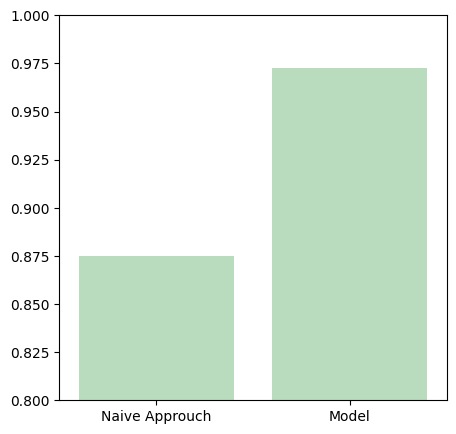

In [159]:
fig = plt.figure(figsize=(5, 5))
plt.ylim(.80, 1)
sns.set_palette("GnBu", 2)
sns.barplot(x = ['Naive Approuch', 'Model'], y=[naiveAcc, modelAcc])
plt.show()

# Predicting the Type of Soil

In [160]:
def classify_soil(row):
    # Alluvial Soil (Fertile, Balanced Nutrients)
    if row['fertility'] == 1:
        if 200 <= row['N'] <= 350 and 10 <= row['P'] <= 40 and 400 <= row['K'] <= 600 and 6.0 <= row['ph'] <= 7.8 and 0.4 <= row['oc'] <= 1.0:
            return 'Alluvial Soil'
        # Black Soil (Rich in Organic Matter)
        elif 250 <= row['N'] <= 350 and 8 <= row['P'] <= 25 and 300 <= row['K'] <= 600 and 6.8 <= row['ph'] <= 8.0 and 0.5 <= row['oc'] <= 1.0:
            return 'Black Soil'
        # Loamy Soil (Balanced, Fertile)
        elif 150 <= row['N'] <= 250 and 8 <= row['P'] <= 30 and 300 <= row['K'] <= 600 and 6.5 <= row['ph'] <= 7.5 and 0.4 <= row['oc'] <= 0.7:
            return 'Loamy Soil'
    # Sandy Soil (Low Fertility, Low Organic Matter)
    elif row['fertility'] == 0:
        if row['N'] < 100 and row['P'] < 10 and row['K'] < 250 and 5.5 <= row['ph'] <= 6.5 and row['oc'] < 0.4:
            return 'Sandy Soil'
        # Red Soil (Low Fertility, Acidic)
        elif 100 <= row['N'] <= 150 and row['P'] < 15 and 150 <= row['K'] <= 300 and 5.5 <= row['ph'] <= 6.5 and row['oc'] < 0.5:
            return 'Red Soil'
    return 'Unclassified'
data['soil_type'] = data.apply(classify_soil, axis=1)

In [161]:
data['soil_type'].value_counts()

soil_type
Unclassified     1214
Black Soil         42
Alluvial Soil      31
Loamy Soil          1
Name: count, dtype: int64

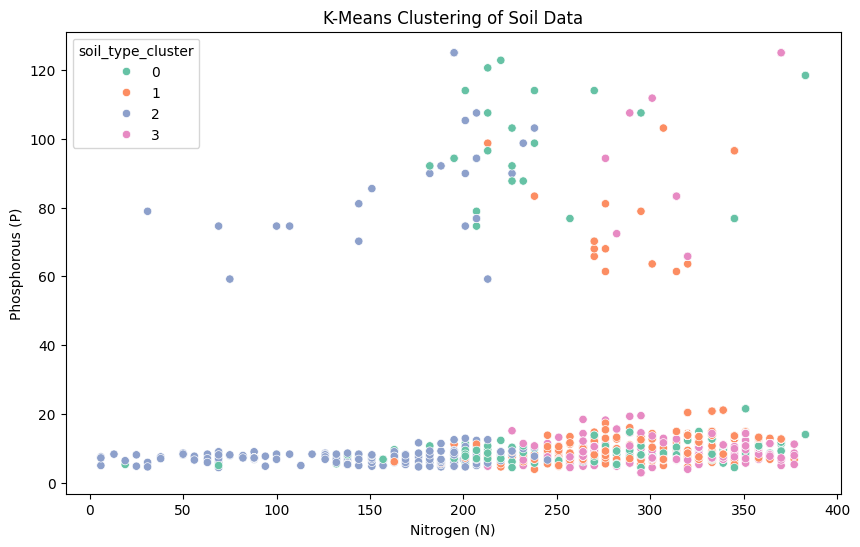

soil_type_cluster
1    486
2    307
3    300
0    195
Name: count, dtype: int64
Cluster Centers:
[[2.79153846e+02 2.65917949e+01 7.05728205e+02 7.47625641e+00
  5.27641026e-01 6.03589744e-01 7.47841026e+00 4.20102564e-01
  3.53312821e+00 8.67538462e-01 8.28271795e+00 7.37897436e-01]
 [3.06903292e+02 1.48925926e+01 3.97043210e+02 7.52255144e+00
  5.29218107e-01 6.71234568e-01 6.50625514e+00 4.47921811e-01
  5.04983539e+00 9.12386831e-01 8.85775720e+00 4.92777778e-01]
 [1.58983713e+02 1.63123779e+01 4.74175896e+02 7.49048860e+00
  5.45276873e-01 6.54039088e-01 8.08827362e+00 4.06416938e-01
  3.70166124e+00 1.05742671e+00 7.48589577e+00 8.06482085e-01]
 [3.13843333e+02 1.76456667e+01 5.47193333e+02 7.69956667e+00
  5.42466667e-01 5.65100000e-01 6.90283333e+00 4.86533333e-01
  3.41973333e+00 7.88366667e-01 9.53533333e+00 5.24100000e-01]]


In [162]:
from sklearn.cluster import KMeans

# Select the relevant features for clustering
features = ['N', 'P', 'K', 'ph', 'ec', 'oc', 'S', 'zn', 'fe', 'cu', 'Mn', 'B']
X = data[features]

# Applying KMeans
kmeans = KMeans(n_clusters=4, random_state=42)  # Assuming 4 clusters based on previous analysis
data['soil_type_cluster'] = kmeans.fit_predict(X)

# Visualize the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x=data['N'], y=data['P'], hue=data['soil_type_cluster'], palette='Set2')
plt.title('K-Means Clustering of Soil Data')
plt.xlabel('Nitrogen (N)')
plt.ylabel('Phosphorous (P)')
plt.show()

# Check the distribution of clusters
print(data['soil_type_cluster'].value_counts())

# Optionally, inspect the cluster centers
print("Cluster Centers:")
print(kmeans.cluster_centers_)

In [163]:
print("Cluster 0: High Nitrogen, Low Phosphorous → Label it as High Nitrogen Soil.\nCluster 1: Moderate levels of nutrients and pH → Label it as Balanced Soil.\nCluster 2: High Potassium, Low Zinc → Label it as High Potassium Soil.\nCluster 3: Low Nitrogen, High Organic Carbon → Label it as Organic Rich Soil.")

Cluster 0: High Nitrogen, Low Phosphorous → Label it as High Nitrogen Soil.
Cluster 1: Moderate levels of nutrients and pH → Label it as Balanced Soil.
Cluster 2: High Potassium, Low Zinc → Label it as High Potassium Soil.
Cluster 3: Low Nitrogen, High Organic Carbon → Label it as Organic Rich Soil.


In [164]:
# Manually assign labels to clusters
cluster_labels = {0: "High Nitrogen Soil", 
                  1: "Balanced Soil", 
                  2: "High Potassium Soil", 
                  3: "Organic Rich Soil"}

# Map the cluster labels to the dataframe
data['soil_type_label'] = data['soil_type_cluster'].map(cluster_labels)

# Check the updated dataframe
print(data[['soil_type_cluster', 'soil_type_label']].head())


   soil_type_cluster      soil_type_label
0                  2  High Potassium Soil
1                  1        Balanced Soil
2                  0   High Nitrogen Soil
3                  2  High Potassium Soil
4                  2  High Potassium Soil


In [165]:
data.head()

,N,P,K,ph,ec,oc,S,zn,fe,cu,Mn,B,fertility,soil_type,soil_type_cluster,soil_type_label
0,138,8.6,560,7.46,0.62,0.70,5.9,0.24,0.31,0.77,8.71,0.11,0,Unclassified,2,High Potassium Soil
1,213,7.5,338,7.62,0.75,1.06,25.4,0.30,0.86,1.54,2.89,2.29,0,Unclassified,1,Balanced Soil
2,163,9.6,718,7.59,0.51,1.11,14.3,0.30,0.86,1.57,2.70,2.03,0,Unclassified,0,High Nitrogen Soil
3,157,6.8,475,7.64,0.58,0.94,26.0,0.34,0.54,1.53,2.65,1.82,0,Unclassified,2,High Potassium Soil
4,220,8.6,444,7.43,0.65,0.72,11.7,0.37,0.66,0.90,2.19,1.82,0,Unclassified,2,High Potassium Soil


In [166]:
X = data[features]  # Features
y = data['soil_type_cluster']  # Target (cluster labels)

# Split dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a RandomForestClassifier
classifier = ensemble.RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(X_train, y_train)

# Predictions and Evaluation
y_pred = classifier.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(classification_report(y_test, y_pred))


Model Accuracy: 96.90%
              precision    recall  f1-score   support

           0       0.97      0.94      0.95        32
           1       0.99      0.96      0.97       100
           2       0.92      0.99      0.95        72
           3       1.00      0.98      0.99        54

    accuracy                           0.97       258
   macro avg       0.97      0.97      0.97       258
weighted avg       0.97      0.97      0.97       258



# Save the Model 

In [167]:
import pickle

with open('random_forest_pkl.pkl', 'wb') as file:
  pickle.dump(model, file)

# Load the Model

In [168]:
with open('random_forest_pkl.pkl', 'rb') as file:
  model = pickle.load(file)
clf.best_params_

{'criterion': 'gini',
 'max_depth': 10,
 'max_features': 'sqrt',
 'n_estimators': 300}